# Evaluación 2 — Programación Científica 2026-1
### Alejandro Sánchez Marín — ID 5385

**Idea central:** una red neuronal aprende sus propias bases para reconstruir
una señal. Aquí comparamos qué pasa si su primera capa arranca en la base de
Fourier vs. una base aleatoria, sobre señales de un medio dispersivo con
regla $\omega(k)=\sqrt{c^2k^2+\mu^2}$.

In [167]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import jax
import jax.numpy as jnp
import warnings
warnings.filterwarnings('ignore')

In [149]:
import os
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

In [150]:
#!sudo apt-get update
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

In [151]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Configuración OK


## Parte I — Datos y capa Fourier

In [152]:
datos = np.load("datos_5385.npz")
X = datos["X"]
y = datos["y"]
t = datos["t"]

### Energía media del dataset

In [153]:
energia_media = (X**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.734


### Construir la capa Fourier

In [166]:
def construir_W1_fourier(N,K):
    t = np.linspace(0, 1, N, endpoint=False)
    W1 = np.zeros((2*K,N))
    for k in range(1, K+1):
        W1[k-1] = np.sin(2 * np.pi * k * t)
        W1[K+k-1] = np.cos(2 * np.pi * k * t)
    return W1

N, K = 256, 15
W1_fourier_init = construir_W1_fourier(N, K)

### Verificación: la capa reproduce `np.fft`

In [156]:
x0 = X[0]
z0 = W1_fourier_init @ x0
z0_sin = z0[:K]
z0_cos = z0[K:]
Xf0 = np.fft.rfft(x0)
sin_fft = -Xf0.imag[1:K+1]
cos_fft = Xf0.real[1:K+1]
print("Error máximo (seno):  ", np.max(np.abs(z0_sin - sin_fft)))
print("Error máximo (coseno):", np.max(np.abs(z0_cos - cos_fft)))

Error máximo (seno):   1.2079226507921703e-13
Error máximo (coseno): 2.9620750296999176e-13


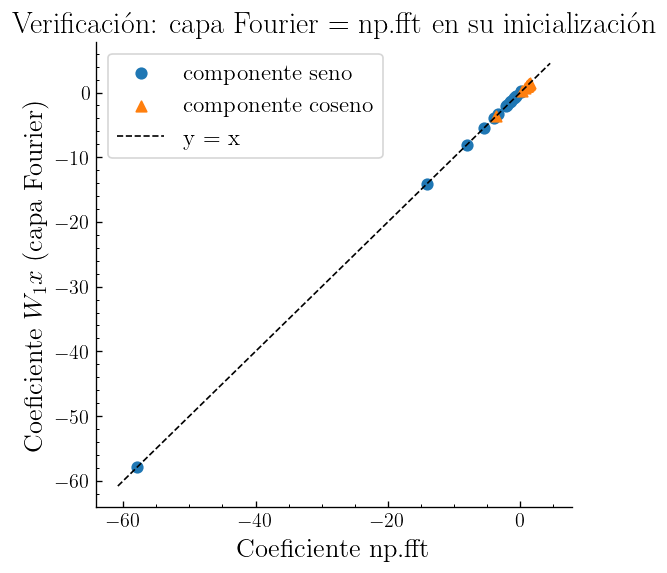

In [157]:
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(sin_fft, z0_sin, label="componente seno", s=40)
ax.scatter(cos_fft, z0_cos, label="componente coseno", s=40, marker='^')
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', linewidth=1, label='y = x')
ax.set_xlabel('Coeficiente np.fft')
ax.set_ylabel('Coeficiente $W_1 x$ (capa Fourier)')
ax.set_title('Verificación: capa Fourier = np.fft en su inicialización')
ax.legend()
plt.tight_layout()
plt.show()

Los puntos caen sobre la recta $y=x$: la capa **es** una transformada de Fourier discreta en su inicialización.

## Parte II — La red en JAX

In [ ]:
def inicializar_params(modo, N, K, seed=0):
    np.random.seed(seed)
    if modo == "fourier":
        W1 = construir_W1_fourier(N, K)
    elif modo == "aleatorio":
        W1 = np.random.randn(2*K, N) * np.sqrt(1.0/N)
    W2 = np.random.randn(N, 2*K) * np.sqrt(1.0/(2*K))
    return {"W1": jnp.array(W1), "W2": jnp.array(W2)}

In [168]:
def forward(params, x):
    z = jnp.tanh(x @ params["W1"].T)
    x_hat = z @ params["W2"].T
    return x_hat

def loss_fn(params, X):
    X_hat = forward_jax(params, X)
    return jnp.mean((X - X_hat)**2)

def error_relativo(params, X):
    X_hat = forward_jax(params, X)
    numerador = jnp.linalg.norm(X_hat - X, axis=1)
    denominador = jnp.linalg.norm(X, axis=1)
    return numerador / denominador

grad_fm = jax.grad(loss_fn)

Prestar especial atención al régimen 1 y a la velocidad con que cada inicialización mejora.

In [169]:
X_jax = jnp.array(X)
y_regimen_atencion = 1 
X_regimen1 = X_jax[y == y_regimen_atencion]
print("X_regimen1.shape:", X_regimen1.shape)

X_regimen1.shape: (12, 256)


## Parte III — Entrenamiento y comparación de inicializaciones

Descenso de gradiente simple, `lr=0.1`, `4000` iteraciones sobre
las 36 señales.

In [170]:
def entrenar(params, X, n_iter=4000, lr=0.1, X_regimen=None):
    historial_loss = []
    historial_err = []
    historial_regimen = []
    for i in range(n_iter):
        grads = grad_fn(params, X)
        params = {
            "W1": params["W1"] - lr * grads["W1"],
            "W2": params["W2"] - lr * grads["W2"],
        }
        historial_loss.append(float(loss_fn(params, X)))
        historial_err.append(float(error_relativo(params, X).mean()))
        if X_regimen is not None:
            historial_regimen.append(float(loss_fn(params, X_regimen)))
    if X_regimen is not None:
        return params, np.array(historial_loss), np.array(historial_err), np.array(historial_regimen)
    else:
        return params, np.array(historial_loss), np.array(historial_err)

In [171]:
params_fourier_0 = inicializar_params("fourier", N, K, seed=0)
params_random_0  = inicializar_params("aleatorio", N, K, seed=0)

params_fourier, hist_fourier, err_fourier, hist_fourier_r1 = entrenar(
    params_fourier_0, X_jax, X_regimen=X_regimen1)
params_random, hist_random, err_random, hist_random_r1 = entrenar(
    params_random_0, X_jax, X_regimen=X_regimen1)

print("Pérdida final Fourier:  ", hist_fourier[-1])
print("Pérdida final Aleatoria:", hist_random[-1])

Pérdida final Fourier:   0.13550417125225067
Pérdida final Aleatoria: 0.10697580128908157


### Reconstrucción: una señal por régimen

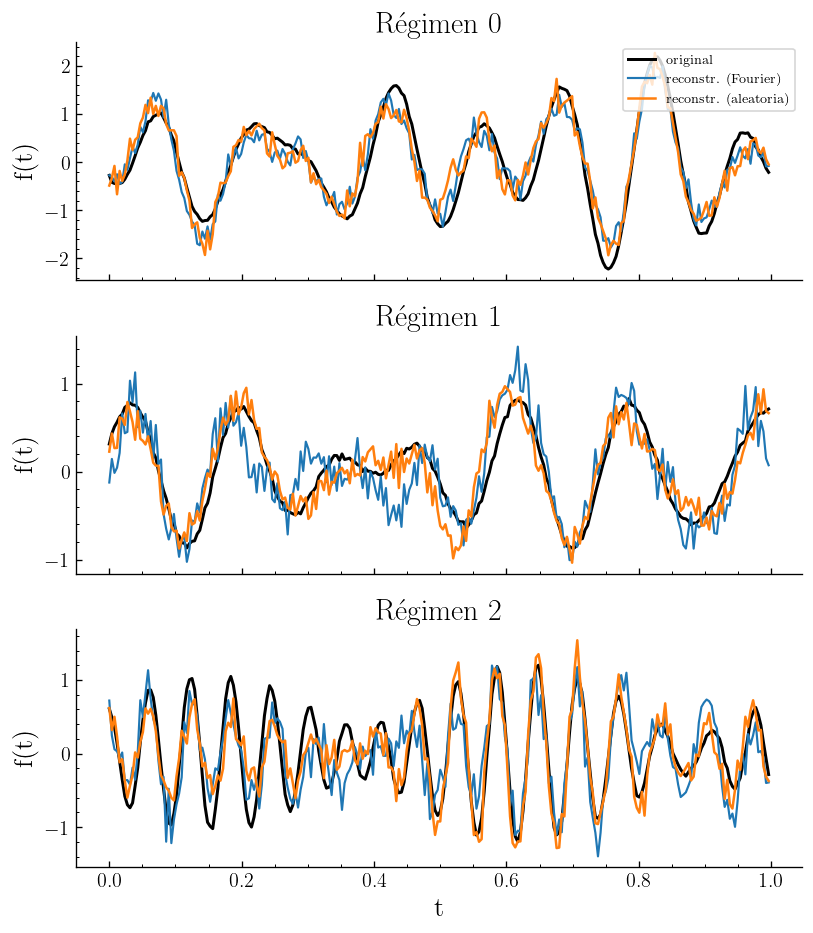

In [175]:
fig, axes = plt.subplots(3, 1, figsize=(7,8), sharex=True)

for i, reg in enumerate([0, 1, 2]):
    idx = np.where(y == reg)[0][0]
    x = X[idx]
    x_hat_fourier = np.array(forward(params_fourier, jnp.array(x)))
    x_hat_random = np.array(forward(params_random, jnp.array(x)))

    axes[i].plot(t, x, 'k-', linewidth=1.8, label='original')
    axes[i].plot(t, x_hat_fourier, '-', linewidth=1.3, label='reconstr. (Fourier)')
    axes[i].plot(t, x_hat_random, '-', linewidth=1.5, label='reconstr. (aleatoria)')
    axes[i].set_title(f'Régimen {reg}')
    axes[i].set_ylabel('f(t)')
    if i == 0:
        axes[i].legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('t')
plt.tight_layout()
plt.show()

### Error relativo final, global y por régimen

In [176]:
err_fourier_final = np.array(error_relativo(params_fourier, X_jax))
err_random_final = np.array(error_relativo(params_random, X_jax))

print("Error relativo medio global:")
print(f"  Fourier:   {err_fourier_final.mean():.4f}")
print(f"  Aleatorio: {err_random_final.mean():.4f}")

print("\nError relativo medio por régimen:")
for reg in [0, 1, 2]:
    mask = (y == reg)
    print(f"  régimen {reg}: Fourier={err_fourier_final[mask].mean():.4f}  "
          f"Aleatorio={err_random_final[mask].mean():.4f}")

Error relativo medio global:
  Fourier:   0.4476
  Aleatorio: 0.3935

Error relativo medio por régimen:
  régimen 0: Fourier=0.4523  Aleatorio=0.4357
  régimen 1: Fourier=0.4423  Aleatorio=0.3914
  régimen 2: Fourier=0.4482  Aleatorio=0.3532


## Comparación de inicializaciones (velocidad de convergencia)

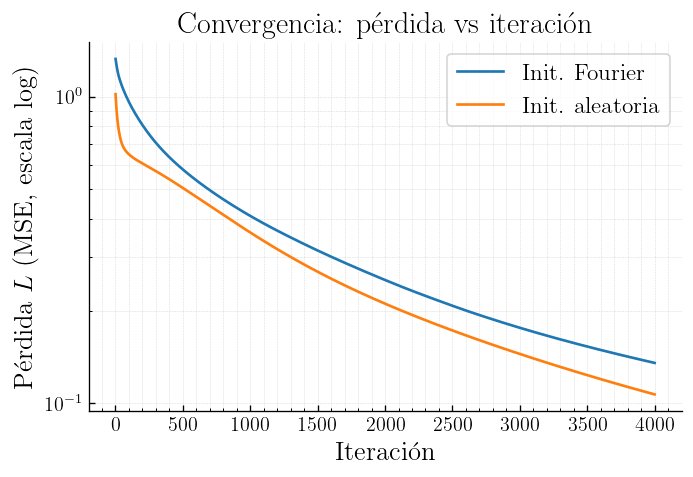

In [177]:
fig, ax = plt.subplots(figsize=(6,4.2))

iteraciones = np.arange(1, len(hist_fourier)+1)
ax.plot(iteraciones, hist_fourier, label='Init. Fourier', linewidth=1.6)
ax.plot(iteraciones, hist_random, label='Init. aleatoria', linewidth=1.6)

ax.set_yscale('log')
ax.set_xlabel('Iteración')
ax.set_ylabel('Pérdida $L$ (MSE, escala log)')
ax.set_title('Convergencia: pérdida vs iteración')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

### Iteraciones para que el error relativo cruce 0.1

In [183]:
def primera_vez_bajo(historial, umbral=0.1):
    idx = np.where(historial < umbral)[0]
    if len(idx) > 0:
        return int(idx[0]) + 1
    else:
        return None

it_fourier = primera_vez_bajo(err_fourier)
it_random = primera_vez_bajo(err_random)
print("Iteraciones para error relativo < 0.1:")
print("  Fourier:  ", it_fourier)
print("  Aleatorio:", it_random)

if it_fourier is None or it_random is None:
    print("\nNinguna (o alguna) inicialización cruza 0.1 en 4000 iteraciones.")
    print("Comparando con umbrales intermedios:")
    for u in [0.9, 0.7, 0.6, 0.5, 0.45]:
        print(f"  umbral {u}: Fourier={primera_vez_bajo(err_fourier,u)}  "
              f"Aleatorio={primera_vez_bajo(err_random,u)}")

Iteraciones para error relativo < 0.1:
  Fourier:   None
  Aleatorio: None

Ninguna (o alguna) inicialización cruza 0.1 en 4000 iteraciones.
Comparando con umbrales intermedios:
  umbral 0.9: Fourier=498  Aleatorio=243
  umbral 0.7: Fourier=1298  Aleatorio=1034
  umbral 0.6: Fourier=2010  Aleatorio=1584
  umbral 0.5: Fourier=3096  Aleatorio=2451
  umbral 0.45: Fourier=3952  Aleatorio=3075


### Régimen 1 — velocidad de mejora

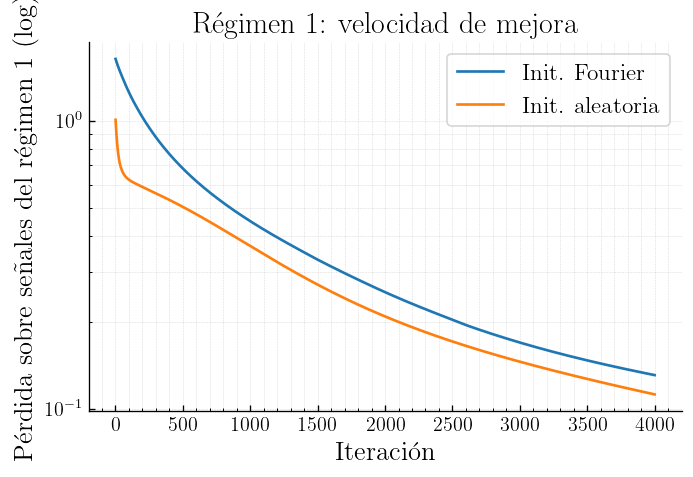

In [179]:
fig, ax = plt.subplots(figsize=(6,4.2))
iteraciones = np.arange(1, len(hist_fourier_r1)+1)
ax.plot(iteraciones, hist_fourier_r1, label='Init. Fourier', linewidth=1.6)
ax.plot(iteraciones, hist_random_r1, label='Init. aleatoria', linewidth=1.6)
ax.set_yscale('log')
ax.set_xlabel('Iteración')
ax.set_ylabel(f'Pérdida sobre señales del régimen {y_regimen_atencion} (log)')
ax.set_title(f'Régimen {y_regimen_atencion}: velocidad de mejora')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Compresión

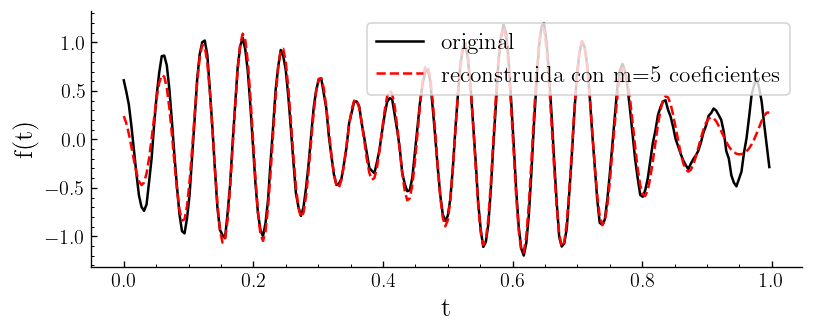

In [187]:
def reconstruir_con_m_coeficientes(x, m):
    Xf = np.fft.rfft(x)
    energia = np.abs(Xf)**2
    orden = np.argsort(-energia)
    Xf_filtrado = np.zeros_like(Xf)
    Xf_filtrado[orden[:m]] = Xf[orden[:m]]
    x_reconstruida = np.fft.irfft(Xf_filtrado, n=len(x))
    return x_reconstruida
x0 = X[0]
x0_m5 = reconstruir_con_m_coeficientes(x0, m=5)

fig, ax = plt.subplots(figsize=(7,3))
ax.plot(t, x0, 'k-', label='original')
ax.plot(t, x0_m5, 'r--', label='reconstruida con m=5 coeficientes')
ax.legend()
ax.set_xlabel('t')
ax.set_ylabel('f(t)')
plt.tight_layout()
plt.show()

In [146]:
def m_para_umbral_energia(x, umbral=0.90):
    Xf = np.fft.rfft(x)
    energia = np.abs(Xf)**2
    energia_ordenada = np.sort(energia)[::-1]
    acumulada = np.cumsum(energia_ordenada) / energia_ordenada.sum()
    m = np.searchsorted(acumulada, umbral) + 1
    return m
ms_90 = [m_para_umbral_energia(x, 0.90) for x in X]
print("Coeficientes para 90% energía:")
print("  media:  ", np.mean(ms_90))
print("  mediana:", np.median(ms_90))
print("  min:", np.min(ms_90), " max:", np.max(ms_90))
ms_90 = []
for x in X:
    ms_90.append(m_para_umbral_energia(x, 0.90))

Coeficientes para 90% energía:
  media:   3.5277777777777777
  mediana: 3.0
  min: 2  max: 9


### Error de reconstrucción vs número de coeficientes conservados

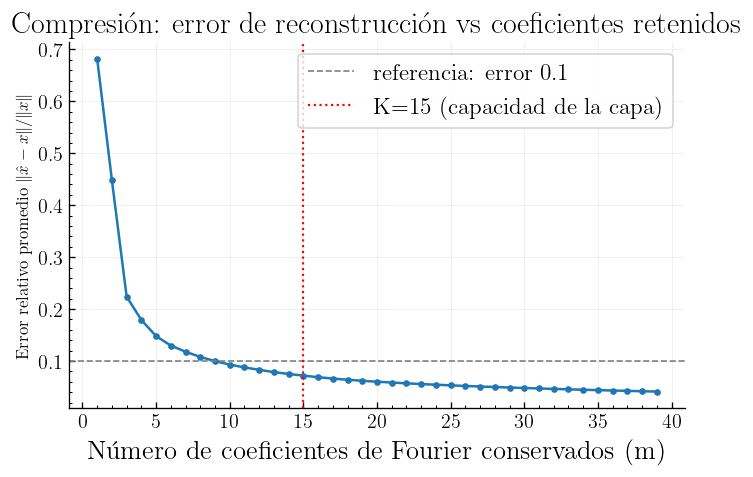

In [ ]:
rango_m = np.arange(1, 40)
errores_promedio = []

for m in rango_m:
    errores_de_esta_m = []
    for x in X:
        x_reconstruida = reconstruir_con_m_coeficientes(x, m)
        error = np.linalg.norm(x_reconstruida - x) / np.linalg.norm(x)
        errores_de_esta_m.append(error)
    errores_promedio.append(np.mean(errores_de_esta_m))

errores_promedio = np.array(errores_promedio)

fig, ax = plt.subplots(figsize=(6,4.2))
ax.plot(rango_m, errores_promedio, marker='o', markersize=3)
ax.axhline(0.1, color='gray', linestyle='--', linewidth=1, label='referencia: error 0.1')
ax.axvline(K, color='red', linestyle=':', linewidth=1.3, label=f'K={K} (capacidad de la capa)')
ax.set_xlabel('Número de coeficientes de Fourier conservados (m)')
ax.set_ylabel(r'Error relativo promedio $\|\hat{x}-x\|/\|x\|$', size=10)
ax.set_title('Compresión: error de reconstrucción vs coeficientes retenidos')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones

- **Capa Fourier**: se verificó que reproduce `np.fft` en su inicialización (error ~1e-13).
- **Convergencia**: En 4000 iteraciones ninguna de las dos inicializacdión cruzó el error relativo de 0.1
- **Régimen 1**: La velocidad de mmejora en el regimen 1 se deistingue la inicializacion de forma aleatoria a la de fourier, lo que le da una ventaja a inicializacion aleatoria.
- **Compresión**: ¿cuántos coeficientes bastaron en promedio para el 90% de la energía,
  y cómo se compara con `2K` (tamaño de la capa entrenable)?
  En promedio bastan ~ 3.5 coeficientes para capturar el 90% de la energía de una señal, la capa 2k usa casi 9 veces más coeficientes.
- No ayudó empezar con la base de Fourier en nuestro caso.
